# PCA vs IPCA vs GIPCA: Synthetic Data Comparison

Simple comparison of three factor models on synthetic data.

**Data Generating Process:**
- $r_{i,t} = z_{i,t}' \Gamma f_t + \epsilon_{i,t}$
- $f_t = \Lambda' m_t + \nu_t$

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

sys.path.insert(0, '../src')
from generalized_ipca import GIPCA
from als_ipca import ALSIPCA

plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

## Generate Synthetic Data

In [2]:
# Dimensions
T = 200      # Time periods
N = 100      # Assets
L = 20       # Characteristics
K = 4        # Latent factors
R = 8        # Macro variables

# Noise levels
sigma_eps = 0.05   # Idiosyncratic return noise
sigma_nu = 0.3     # Factor noise

print(f"Dimensions: T={T}, N={N}, L={L}, K={K}, R={R}")

Dimensions: T=200, N=100, L=20, K=4, R=8


In [3]:
# True parameters
np.random.seed(42)

# True Gamma (L x K) - orthonormalized
true_Gamma = np.random.randn(L, K)
true_Gamma, _ = np.linalg.qr(true_Gamma)
true_Gamma = true_Gamma[:, :K]

# True Lambda (R x K)
true_Lambda = np.random.randn(R, K) * 0.5

# Macro variables (persistent AR(1))
rho = 0.9
M = np.zeros((T, R))
M[0] = np.random.randn(R)
for t in range(1, T):
    M[t] = rho * M[t-1] + np.sqrt(1 - rho**2) * np.random.randn(R)
M = (M - M.mean(axis=0)) / M.std(axis=0)

# Factors: f_t = Lambda' m_t + noise
true_factors = M @ true_Lambda + np.random.randn(T, K) * sigma_nu

# Characteristics (time-varying)
Z = np.zeros((T, N, L))
Z[0] = np.random.randn(N, L) * 0.5
for t in range(1, T):
    Z[t] = 0.8 * Z[t-1] + 0.2 * np.random.randn(N, L) * 0.5
Z[:, :, 0] = 1.0  # Intercept

# Returns: r_{i,t} = z_{i,t}' Gamma f_t + noise
returns = np.zeros((T, N))
for t in range(T):
    loadings_t = Z[t] @ true_Gamma
    returns[t] = loadings_t @ true_factors[t] + np.random.randn(N) * sigma_eps

print(f"Returns shape: {returns.shape}")
print(f"Returns std: {returns.std():.4f}")

Returns shape: (200, 100)
Returns std: 0.5153


In [4]:
# Train/Test split (70/30)
split_idx = int(0.7 * T)

train_returns, test_returns = returns[:split_idx], returns[split_idx:]
train_Z, test_Z = Z[:split_idx], Z[split_idx:]
train_M, test_M = M[:split_idx], M[split_idx:]

T_train, T_test = train_returns.shape[0], test_returns.shape[0]
print(f"Train: {T_train} periods, Test: {T_test} periods")

Train: 140 periods, Test: 60 periods


## Fit Models

In [5]:
def compute_r2(y_true, y_pred):
    """Compute R-squared."""
    ss_res = np.sum((y_true - y_pred) ** 2)
    ss_tot = np.sum((y_true - y_true.mean()) ** 2)
    return 1 - ss_res / ss_tot

In [6]:
# === PCA ===
pca = PCA(n_components=K)
pca.fit(train_returns)

# In-sample
pca_train_pred = pca.inverse_transform(pca.transform(train_returns))
pca_r2_train = compute_r2(train_returns, pca_train_pred)

# Out-of-sample
pca_test_pred = pca.inverse_transform(pca.transform(test_returns))
pca_r2_test = compute_r2(test_returns, pca_test_pred)

print(f"PCA: IS R²={pca_r2_train*100:.2f}%, OOS R²={pca_r2_test*100:.2f}%")

PCA: IS R²=67.87%, OOS R²=45.37%


In [7]:
# === IPCA ===
ipca = ALSIPCA(num_assets=N, num_fact=K, num_charact=L, win_len=T_train)
ipca.fit(data=[train_returns, train_Z], max_iter=200, tol=1e-6, verbose=False, seed=42)

ipca_Gamma = ipca.Gamma.values
ipca_factors = ipca.factors.values  # K x T

# In-sample
ipca_train_pred = np.zeros_like(train_returns)
for t in range(T_train):
    ipca_train_pred[t] = (train_Z[t] @ ipca_Gamma) @ ipca_factors[:, t]
ipca_r2_train = compute_r2(train_returns, ipca_train_pred)

# Out-of-sample: estimate factors via cross-sectional regression
ipca_test_pred = np.zeros_like(test_returns)
for t in range(T_test):
    loadings_t = test_Z[t] @ ipca_Gamma
    f_t, *_ = np.linalg.lstsq(loadings_t, test_returns[t], rcond=None)
    ipca_test_pred[t] = loadings_t @ f_t
ipca_r2_test = compute_r2(test_returns, ipca_test_pred)

print(f"IPCA: IS R²={ipca_r2_train*100:.2f}%, OOS R²={ipca_r2_test*100:.2f}%")
print(f"  Converged in {ipca.n_iterations} iterations")

IPCA: IS R²=99.20%, OOS R²=98.63%
  Converged in 8 iterations


In [8]:
# === GIPCA ===
gipca = GIPCA(num_assets=N, num_fact=K, num_charact=L, num_macro=R, win_len=T_train, alpha=1.0)
gipca.fit(data=[train_returns, train_Z, train_M], max_iter=200, tol=1e-6, verbose=False, seed=42)

gipca_Gamma = gipca.Gamma.values
gipca_Lambda = gipca.Lambda.values
gipca_factors = gipca.factors.values  # K x T

# In-sample
gipca_train_pred = np.zeros_like(train_returns)
for t in range(T_train):
    gipca_train_pred[t] = (train_Z[t] @ gipca_Gamma) @ gipca_factors[:, t]
gipca_r2_train = compute_r2(train_returns, gipca_train_pred)

# Out-of-sample: estimate factors via cross-sectional regression
gipca_test_pred = np.zeros_like(test_returns)
for t in range(T_test):
    loadings_t = test_Z[t] @ gipca_Gamma
    f_t, *_ = np.linalg.lstsq(loadings_t, test_returns[t], rcond=None)
    gipca_test_pred[t] = loadings_t @ f_t
gipca_r2_test = compute_r2(test_returns, gipca_test_pred)

print(f"GIPCA: IS R²={gipca_r2_train*100:.2f}%, OOS R²={gipca_r2_test*100:.2f}%")
print(f"  Converged in {gipca.n_iterations} iterations")

GIPCA: IS R²=72.98%, OOS R²=98.25%
  Converged in 200 iterations


## Summary

In [9]:
print("=" * 50)
print("MODEL COMPARISON (Synthetic Data)")
print("=" * 50)
print(f"{'Model':<20} {'In-Sample':>12} {'Out-of-Sample':>14}")
print("-" * 50)
print(f"{'PCA':<20} {pca_r2_train*100:>11.2f}% {pca_r2_test*100:>13.2f}%")
print(f"{'IPCA':<20} {ipca_r2_train*100:>11.2f}% {ipca_r2_test*100:>13.2f}%")
print(f"{'GIPCA':<20} {gipca_r2_train*100:>11.2f}% {gipca_r2_test*100:>13.2f}%")
print("=" * 50)

MODEL COMPARISON (Synthetic Data)
Model                   In-Sample  Out-of-Sample
--------------------------------------------------
PCA                        67.87%         45.37%
IPCA                       99.20%         98.63%
GIPCA                      72.98%         98.25%


## Parameter Recovery

In [10]:
def subspace_distance(A, B):
    """Grassmann distance between column spaces."""
    Qa, _ = np.linalg.qr(A)
    Qb, _ = np.linalg.qr(B)
    s = np.linalg.svd(Qa.T @ Qb, compute_uv=False)
    s = np.clip(s, -1, 1)
    return np.sqrt(np.sum(np.arccos(s)**2))

ipca_dist = subspace_distance(true_Gamma, ipca_Gamma)
gipca_dist = subspace_distance(true_Gamma, gipca_Gamma)

print("Gamma Recovery (Grassmann distance, lower=better):")
print(f"  IPCA:  {ipca_dist:.4f}")
print(f"  GIPCA: {gipca_dist:.4f}")

Gamma Recovery (Grassmann distance, lower=better):
  IPCA:  0.0258
  GIPCA: 0.1874


## Visualizations

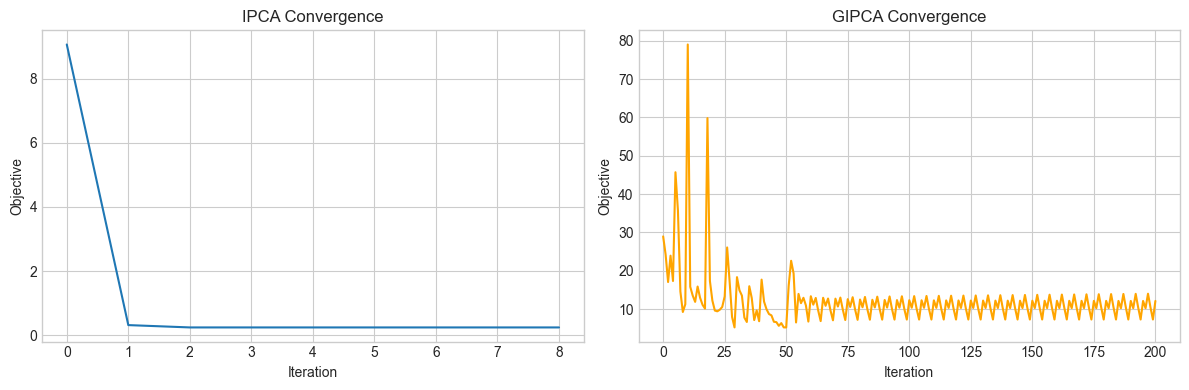

In [11]:
# Convergence
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(ipca.objective_history)
axes[0].set_xlabel('Iteration')
axes[0].set_ylabel('Objective')
axes[0].set_title('IPCA Convergence')

axes[1].plot(gipca.objective_history, color='orange')
axes[1].set_xlabel('Iteration')
axes[1].set_ylabel('Objective')
axes[1].set_title('GIPCA Convergence')

plt.tight_layout()
plt.show()

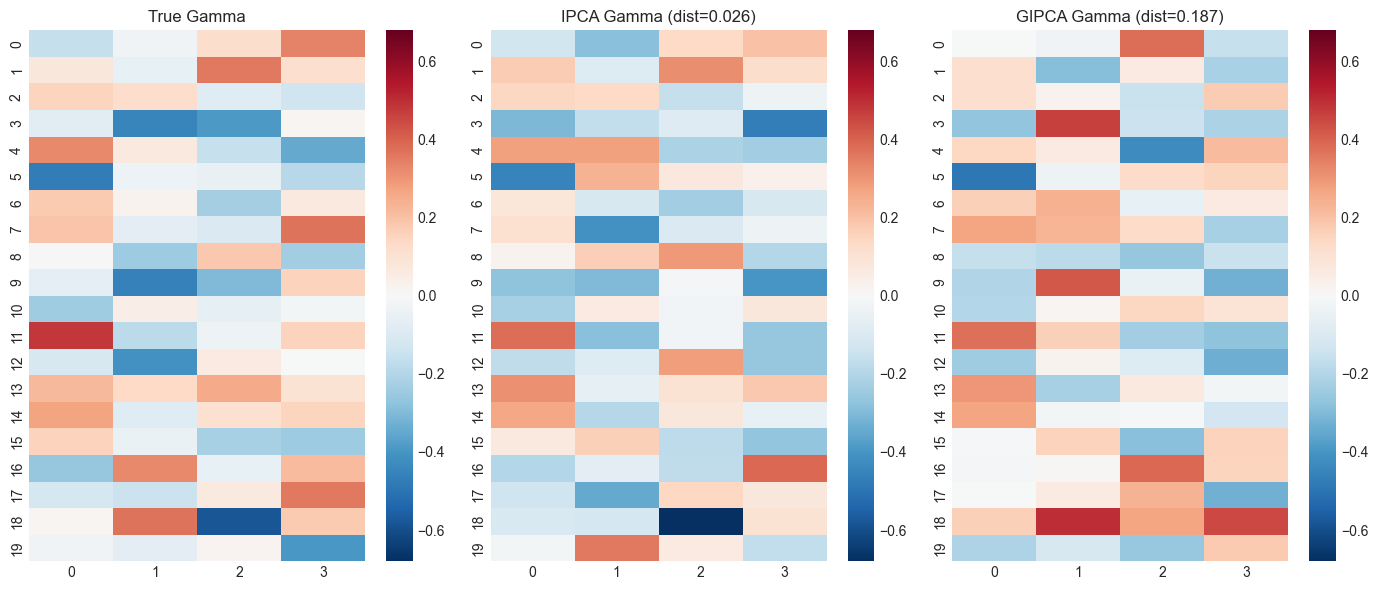

In [12]:
# Gamma heatmaps
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

vmax = max(np.abs(true_Gamma).max(), np.abs(ipca_Gamma).max(), np.abs(gipca_Gamma).max())

sns.heatmap(true_Gamma, ax=axes[0], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[0].set_title('True Gamma')

sns.heatmap(ipca_Gamma, ax=axes[1], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[1].set_title(f'IPCA Gamma (dist={ipca_dist:.3f})')

sns.heatmap(gipca_Gamma, ax=axes[2], cmap='RdBu_r', center=0, vmin=-vmax, vmax=vmax)
axes[2].set_title(f'GIPCA Gamma (dist={gipca_dist:.3f})')

plt.tight_layout()
plt.show()

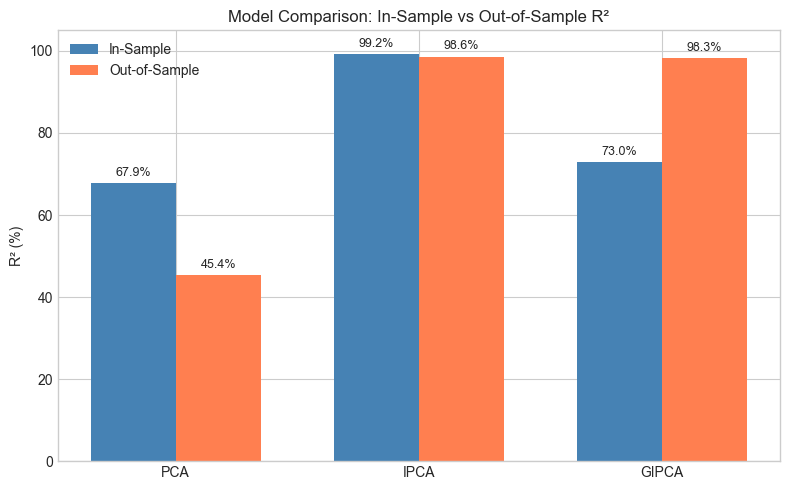

In [13]:
# R² comparison bar chart
fig, ax = plt.subplots(figsize=(8, 5))

models = ['PCA', 'IPCA', 'GIPCA']
is_r2 = [pca_r2_train*100, ipca_r2_train*100, gipca_r2_train*100]
oos_r2 = [pca_r2_test*100, ipca_r2_test*100, gipca_r2_test*100]

x = np.arange(len(models))
width = 0.35

bars1 = ax.bar(x - width/2, is_r2, width, label='In-Sample', color='steelblue')
bars2 = ax.bar(x + width/2, oos_r2, width, label='Out-of-Sample', color='coral')

ax.set_ylabel('R² (%)')
ax.set_title('Model Comparison: In-Sample vs Out-of-Sample R²')
ax.set_xticks(x)
ax.set_xticklabels(models)
ax.legend()
ax.set_ylim(0, 105)

# Add value labels
for bar in bars1 + bars2:
    height = bar.get_height()
    ax.annotate(f'{height:.1f}%', xy=(bar.get_x() + bar.get_width()/2, height),
                xytext=(0, 3), textcoords='offset points', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

## Sensitivity: Varying Noise Levels

In [14]:
def run_experiment(sigma_eps_val, sigma_nu_val, seed=42):
    """Run experiment with given noise levels."""
    np.random.seed(seed)
    
    # Generate data with new noise
    factors = M @ true_Lambda + np.random.randn(T, K) * sigma_nu_val
    rets = np.zeros((T, N))
    for t in range(T):
        rets[t] = (Z[t] @ true_Gamma) @ factors[t] + np.random.randn(N) * sigma_eps_val
    
    train_rets, test_rets = rets[:split_idx], rets[split_idx:]
    
    results = {}
    
    # PCA
    pca = PCA(n_components=K)
    pca.fit(train_rets)
    results['pca_is'] = compute_r2(train_rets, pca.inverse_transform(pca.transform(train_rets)))
    results['pca_oos'] = compute_r2(test_rets, pca.inverse_transform(pca.transform(test_rets)))
    
    # IPCA
    ipca = ALSIPCA(num_assets=N, num_fact=K, num_charact=L, win_len=T_train)
    ipca.fit(data=[train_rets, train_Z], max_iter=100, tol=1e-5, verbose=False, seed=seed)
    ipca_G = ipca.Gamma.values
    ipca_f = ipca.factors.values
    
    ipca_train_p = np.array([(train_Z[t] @ ipca_G) @ ipca_f[:, t] for t in range(T_train)])
    results['ipca_is'] = compute_r2(train_rets, ipca_train_p)
    
    ipca_test_p = np.zeros_like(test_rets)
    for t in range(T_test):
        L_t = test_Z[t] @ ipca_G
        f_t, *_ = np.linalg.lstsq(L_t, test_rets[t], rcond=None)
        ipca_test_p[t] = L_t @ f_t
    results['ipca_oos'] = compute_r2(test_rets, ipca_test_p)
    
    # GIPCA
    gipca = GIPCA(num_assets=N, num_fact=K, num_charact=L, num_macro=R, win_len=T_train, alpha=1.0)
    gipca.fit(data=[train_rets, train_Z, train_M], max_iter=100, tol=1e-5, verbose=False, seed=seed)
    gipca_G = gipca.Gamma.values
    gipca_f = gipca.factors.values
    
    gipca_train_p = np.array([(train_Z[t] @ gipca_G) @ gipca_f[:, t] for t in range(T_train)])
    results['gipca_is'] = compute_r2(train_rets, gipca_train_p)
    
    gipca_test_p = np.zeros_like(test_rets)
    for t in range(T_test):
        L_t = test_Z[t] @ gipca_G
        f_t, *_ = np.linalg.lstsq(L_t, test_rets[t], rcond=None)
        gipca_test_p[t] = L_t @ f_t
    results['gipca_oos'] = compute_r2(test_rets, gipca_test_p)
    
    return results

In [15]:
# Vary idiosyncratic noise
sigma_eps_vals = [0.01, 0.05, 0.1, 0.2, 0.5]
results_eps = {s: run_experiment(s, 0.3) for s in sigma_eps_vals}

print("Effect of Idiosyncratic Noise (sigma_eps):")
print(f"{'sigma_eps':<10} {'PCA IS':>10} {'PCA OOS':>10} {'IPCA IS':>10} {'IPCA OOS':>10} {'GIPCA IS':>10} {'GIPCA OOS':>10}")
print("-" * 75)
for s in sigma_eps_vals:
    r = results_eps[s]
    print(f"{s:<10} {r['pca_is']*100:>9.1f}% {r['pca_oos']*100:>9.1f}% {r['ipca_is']*100:>9.1f}% {r['ipca_oos']*100:>9.1f}% {r['gipca_is']*100:>9.1f}% {r['gipca_oos']*100:>9.1f}%")

Effect of Idiosyncratic Noise (sigma_eps):
sigma_eps      PCA IS    PCA OOS    IPCA IS   IPCA OOS   GIPCA IS  GIPCA OOS
---------------------------------------------------------------------------
0.01            67.5%      47.1%     100.0%      99.9%      93.7%      99.9%
0.05            66.9%      46.4%      99.2%      98.7%      86.1%      98.3%
0.1             65.4%      44.6%      96.9%      94.9%      54.8%      94.9%
0.2             60.0%      38.6%      88.5%      82.3%      60.9%      81.8%
0.5             39.4%      20.5%      56.0%      42.9%      52.7%      42.8%


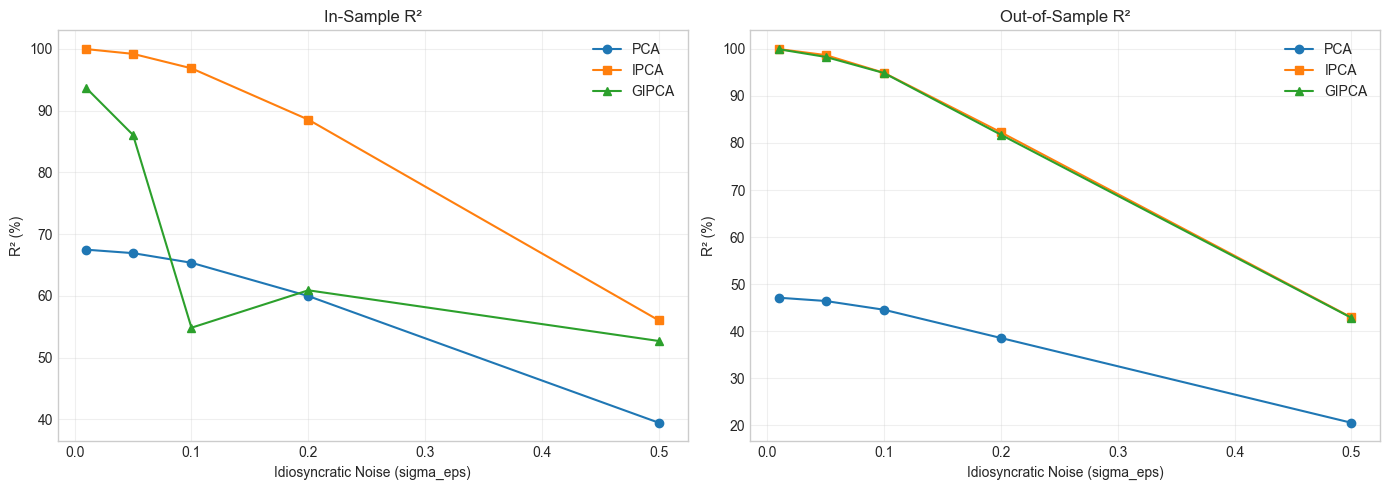

In [16]:
# Plot sensitivity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# In-sample
axes[0].plot(sigma_eps_vals, [results_eps[s]['pca_is']*100 for s in sigma_eps_vals], 'o-', label='PCA')
axes[0].plot(sigma_eps_vals, [results_eps[s]['ipca_is']*100 for s in sigma_eps_vals], 's-', label='IPCA')
axes[0].plot(sigma_eps_vals, [results_eps[s]['gipca_is']*100 for s in sigma_eps_vals], '^-', label='GIPCA')
axes[0].set_xlabel('Idiosyncratic Noise (sigma_eps)')
axes[0].set_ylabel('R² (%)')
axes[0].set_title('In-Sample R²')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Out-of-sample
axes[1].plot(sigma_eps_vals, [results_eps[s]['pca_oos']*100 for s in sigma_eps_vals], 'o-', label='PCA')
axes[1].plot(sigma_eps_vals, [results_eps[s]['ipca_oos']*100 for s in sigma_eps_vals], 's-', label='IPCA')
axes[1].plot(sigma_eps_vals, [results_eps[s]['gipca_oos']*100 for s in sigma_eps_vals], '^-', label='GIPCA')
axes[1].set_xlabel('Idiosyncratic Noise (sigma_eps)')
axes[1].set_ylabel('R² (%)')
axes[1].set_title('Out-of-Sample R²')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()